# I.1 — Fibonacci & the Golden Ratio

No worksheet tonight. No marking. You're here to build something beautiful and own every line of it.

The whole interlude runs on one rule — a **recurrence**, meaning each value is built from earlier ones:

$$F(n) = F(n-1) + F(n-2)$$

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# The recurrence, as a loop. `fib` is a list; .append() adds one item to its end.
fib = [1, 1]                        # the two seed values, F(1) and F(2)
for n in range(18):                 # ...and 18 more
    fib.append(fib[-1] + fib[-2])   # the ENTIRE rule: last + second-last
                                    # (fib[-1] means "last item", fib[-2] "second-last")
print(fib)

[1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765]


In [3]:
# Now divide each number by the one before it, and watch where the ratios head.
# (f"..." is an f-string: the {} slots get filled in; :.10f means 10 decimal places.)
for i in range(1, 12):
    print(f"F({i+1}) / F({i})  =  {fib[i]:>3} / {fib[i-1]:>3}  =  {fib[i] / fib[i-1]:.10f}")

phi = (1 + np.sqrt(5)) / 2          # the golden ratio, written exactly
print(f"\nphi              =  {phi:.10f}")

F(2) / F(1)  =    1 /   1  =  1.0000000000
F(3) / F(2)  =    2 /   1  =  2.0000000000
F(4) / F(3)  =    3 /   2  =  1.5000000000
F(5) / F(4)  =    5 /   3  =  1.6666666667
F(6) / F(5)  =    8 /   5  =  1.6000000000
F(7) / F(6)  =   13 /   8  =  1.6250000000
F(8) / F(7)  =   21 /  13  =  1.6153846154
F(9) / F(8)  =   34 /  21  =  1.6190476190
F(10) / F(9)  =   55 /  34  =  1.6176470588
F(11) / F(10)  =   89 /  55  =  1.6181818182
F(12) / F(11)  =  144 /  89  =  1.6179775281

phi              =  1.6180339887


The ratios don't drift — they **converge**, hammering in on $\varphi = \frac{1+\sqrt 5}{2}$ from
both sides, closer with every term. Any two starting numbers would end up at the same place.
The sequence doesn't contain φ; the *rule* does.

## The golden spiral

A golden spiral grows its radius by a factor of φ every quarter turn — the shape of nautilus
shells, cyclone arms, and (roughly) spiral galaxies. That's one line of math: $r = \varphi^{\theta / (\pi/2)}$.

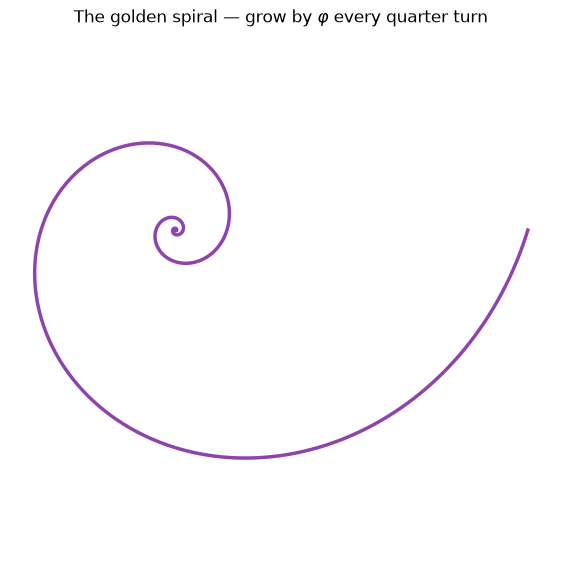

In [4]:
# np.linspace(a, b, n) = n evenly spaced values from a to b. Here: an angle sweeping 4 full turns.
theta = np.linspace(0, 8 * np.pi, 2000)
r = phi ** (theta / (np.pi / 2))          # multiply by phi every quarter turn

plt.figure(figsize=(7, 7))
plt.plot(r * np.cos(theta), r * np.sin(theta), color="#8e44ad", linewidth=2.5)
plt.axis("equal")                         # 1 unit across = 1 unit up, or the spiral squashes
plt.axis("off")                           # no chart junk — this is art
plt.title("The golden spiral — grow by $\\varphi$ every quarter turn")
plt.show()

## Grow a sunflower

A sunflower places its seeds one at a time from the centre, each new seed rotated a fixed angle
from the last. Nature's chosen angle is the **golden angle**, the full circle divided by φ:
$360° / \varphi \approx 222.5°$, i.e. $137.5°$ measured the short way. The rule for seed $n$:

$$r = \sqrt{n}, \qquad \theta = n \times 137.5°$$

($\sqrt{n}$ keeps the seeds evenly packed — the area of a circle grows with $r^2$, so radius must grow with $\sqrt{n}$.)

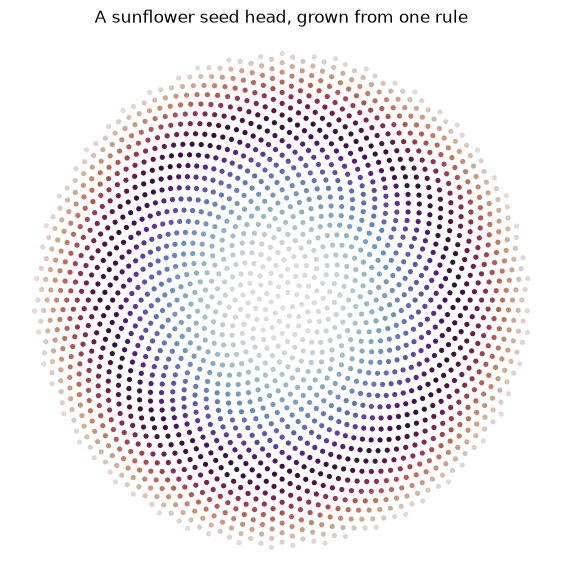

In [5]:
n = np.arange(1, 2000)              # seed numbers 1..1999 — a whole array, no loop needed
theta = n * np.deg2rad(137.5)       # every seed turns 137.5 deg further round (deg2rad: degrees -> radians)
r = np.sqrt(n)

plt.figure(figsize=(7, 7))
plt.scatter(r * np.cos(theta), r * np.sin(theta),
            s=14, c=n, cmap="twilight", edgecolors="none")   # colour each seed by its birth order
plt.axis("equal")
plt.axis("off")
plt.title("A sunflower seed head, grown from one rule")
plt.show()

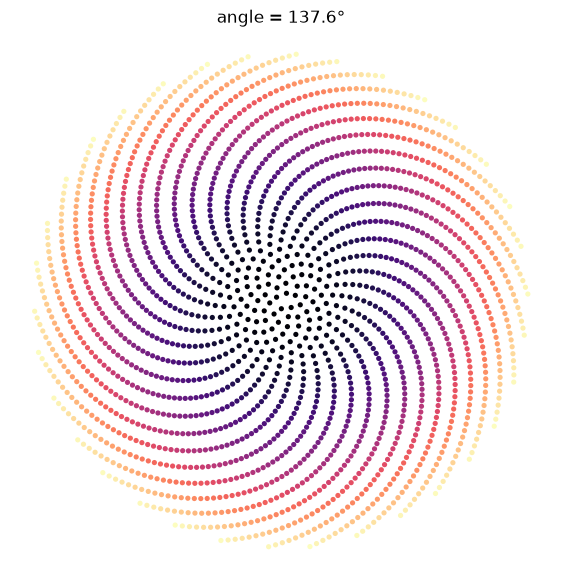

In [6]:
# YOUR TURN — break the flower. The ONLY thing that changes is the angle. Try:
#   137.6                                (one tenth of a degree off — watch it unravel)
#   137.3
#   90, 120, 144                         (the "nice" angles — spokes, stripes, wasted space)
#   360 - 360 / phi                      (the exact golden angle — why does this one win?)
angle_degrees = 137.6

theta = n * np.deg2rad(angle_degrees)
plt.figure(figsize=(7, 7))
plt.scatter(np.sqrt(n) * np.cos(theta), np.sqrt(n) * np.sin(theta),
            s=14, c=n, cmap="magma", edgecolors="none")
plt.axis("equal")
plt.axis("off")
plt.title(f"angle = {angle_degrees}°")
plt.show()

## What you just saw

φ is provably the **most irrational number** — the hardest to approximate with any fraction.
Every "nicer" angle eventually lines seeds up into spokes and wastes space; the golden angle
never repeats, so every seed falls into fresh gap. Sunflowers found by evolution what you just
found with a for-loop. The flower isn't *using* math — the flower and the math are the same
pattern, seen twice.

And notice what tonight actually was: a recurrence, ratios, and loops — Module 0, wearing petals.

**The thread of this whole track:** simple rules, iterated, create the complexity of nature.
Hold onto that, because a neural network is exactly this kind of object — simple math,
composed and repeated, until something you'd swear was designed emerges.

*Done? Tell Claude which angle surprised you most. Next module awaits.*